# MNIST Optimizer Validation

Replace Adam with your optimizer and compare results.

In [1]:
import random, numpy as np, torch, torch.nn as nn, matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

In [2]:
SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE='cuda' if torch.cuda.is_available() else 'cpu'
print(DEVICE)

cpu


In [3]:
transform=transforms.ToTensor()
dataset=MNIST(root='./data',train=True,download=True,transform=transform)
train_dataset,val_dataset=random_split(dataset,[50000,10000])
test_dataset=MNIST(root='./data',train=False,download=True,transform=transform)
train_loader=DataLoader(train_dataset,batch_size=128,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=256)
test_loader=DataLoader(test_dataset,batch_size=256)

In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(784,1024),nn.ReLU(),
            nn.Linear(1024,1024),nn.ReLU(),
            nn.Linear(1024,10))
    def forward(self,x):
        return self.net(x.view(x.size(0),-1))

model=MLP().to(DEVICE)
criterion=nn.CrossEntropyLoss()

# optimizer=torch.optim.Adam(model.parameters(),lr=1e-3)
# replace with your optimizer

In [10]:
import torch
from torch.optim import Optimizer

class AdamWithEpsBar(Optimizer):
    def __init__(self, params, lr=0.001, betas=(0.9, 0.999), eps=1e-9, eps_bar=0.0):
        defaults = dict(lr=lr, betas=betas, eps=eps, eps_bar=eps_bar)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            lr       = group['lr']
            b1, b2   = group['betas']
            eps      = group['eps']
            eps_bar  = group['eps_bar']

            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad
                state = self.state[p]

                # Initialize state
                if len(state) == 0:
                    state['step'] = 0
                    state['m'] = torch.zeros_like(p)   # 1st moment
                    state['v'] = torch.zeros_like(p)   # 2nd moment

                m, v = state['m'], state['v']
                state['step'] += 1
                t = state['step']

                # Moment updates
                m.mul_(b1).add_(grad, alpha=1 - b1)
                v.mul_(b2).addcmul_(grad, grad, value=1 - b2)

                # Bias correction
                m_hat = m / (1 - b1 ** t)
                v_hat = v / (1 - b2 ** t)

                v_hat = v_hat + eps_bar  # add eps_bar inside the sqrt for stability

                update = m_hat / (v_hat.sqrt() + eps)  # standard Adam update

                p.add_(update, alpha=-lr)

In [18]:
optimizer = AdamWithEpsBar(
    model.parameters(),
    lr=1e-3,
    betas=(0.9, 0.9),
    eps=1e-9,
    eps_bar=1e-3
)

In [19]:
@torch.no_grad()
def evaluate(model,loader):
    model.eval()
    correct=total=0; loss_sum=0
    for x,y in loader:
        x,y=x.to(DEVICE),y.to(DEVICE)
        logits=model(x)
        loss=criterion(logits,y)
        pred=logits.argmax(1)
        correct+=(pred==y).sum().item()
        total+=y.size(0)
        loss_sum+=loss.item()
    return correct/total, loss_sum/len(loader)

In [20]:
EPOCHS=20
train_accs=[]; val_accs=[]; train_losses=[]; val_losses=[]

for epoch in range(EPOCHS):
    model.train()
    running_loss=0; correct=0; total=0

    for x,y in train_loader:
        x,y=x.to(DEVICE),y.to(DEVICE)
        optimizer.zero_grad()
        logits=model(x)
        loss=criterion(logits,y)
        loss.backward()
        optimizer.step()

        running_loss+=loss.item()
        pred=logits.argmax(1)
        correct+=(pred==y).sum().item()
        total+=y.size(0)

    train_acc=correct/total
    train_loss=running_loss/len(train_loader)
    val_acc,val_loss=evaluate(model,val_loader)

    train_accs.append(train_acc); val_accs.append(val_acc)
    train_losses.append(train_loss); val_losses.append(val_loss)

    print(epoch+1, train_acc, val_acc)

1 0.99912 0.9807
2 0.99964 0.9813
3 0.99982 0.9815
4 0.9999 0.9814
5 0.99994 0.9814
6 0.99998 0.9815
7 1.0 0.9817
8 1.0 0.9818
9 1.0 0.9818
10 1.0 0.9818
11 1.0 0.9821
12 1.0 0.9821
13 1.0 0.9821
14 1.0 0.982
15 1.0 0.9821
16 1.0 0.9823
17 1.0 0.9826
18 1.0 0.9826
19 1.0 0.9828
20 1.0 0.9827


In [15]:
test_acc,test_loss=evaluate(model,test_loader)
print('Test Accuracy:',test_acc)

Test Accuracy: 0.9821


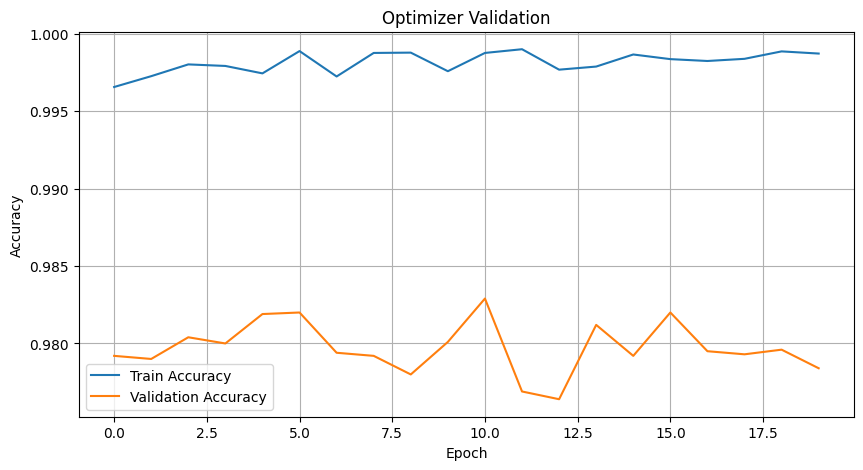

In [16]:
plt.figure(figsize=(10,5))
plt.plot(train_accs,label='Train Accuracy')
plt.plot(val_accs,label='Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('Optimizer Validation')
plt.legend(); plt.grid(True); plt.show()

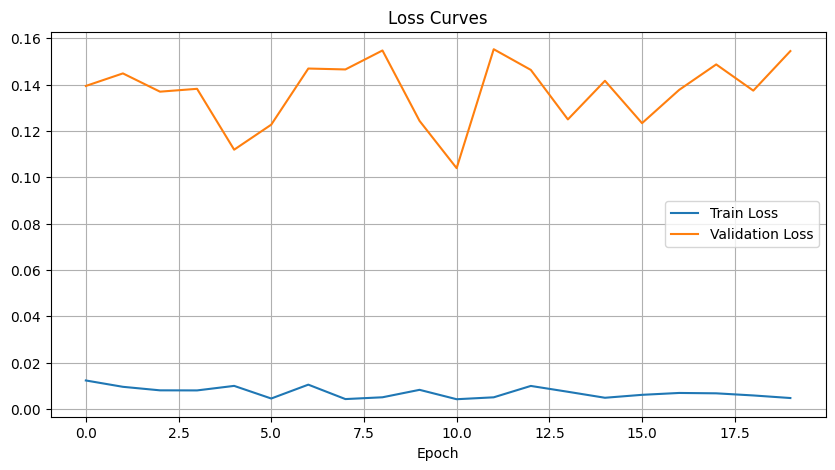

In [17]:
plt.figure(figsize=(10,5))
plt.plot(train_losses,label='Train Loss')
plt.plot(val_losses,label='Validation Loss')
plt.xlabel('Epoch'); pltylabel='Loss'
plt.title('Loss Curves')
plt.legend(); plt.grid(True); plt.show()